In [1]:
%%capture
%run "/Users/katbutler/MetabolicCost/metCostMod-Result.ipynb"

In [2]:
import math

analyzed = set()
dfCount = 1
for subject in result.keys():
    indShiftDict = {}
    if subject[0] in analyzed:
        continue
    analyzed.add(subject[0])
    for activity in result.keys():
    
        if activity[1] in indShiftDict:
            continue
            
        if activity[1] not in result[subject[0]]:
            continue

        ind = result[subject[0]][activity[1]]['EMG']['Data'][:, code]
        indShift = np.where((ind[:-1] - ind[1:]) != 0)[0]
        
        
        indShiftDict[activity[1]] = indShift

    # Convert to DataFrame for the subject
    indDF = pd.DataFrame(dict([(key, pd.Series(value)) for key, value in indShiftDict.items()]))
    indDF = indDF.fillna(0)
    indDF = indDF/1000
    indDF = np.ceil(indDF)
    
    if dfCount <= 10:
        if dfCount < 10:
            exec(f"Subject0{dfCount} = indDF")
            dfCount += 1
        else:
            exec(f"Subject{dfCount} = indDF")
            dfCount += 1
    print(indDF)
# print(Subject01)

   Backwards  Cycling  Incline  Running  Walking
0      360.0    360.0    360.0    360.0    360.0
1      720.0    720.0    720.0    720.0    720.0
2     1080.0   1080.0   1080.0   1080.0   1080.0
3     1440.0   1440.0   1440.0   1440.0   1440.0
4        0.0   1800.0   1800.0      0.0      0.0
5        0.0      0.0   2160.0      0.0      0.0
   Backwards  Cycling  Incline  Running  Walking  Backwards2  Stairs
0      360.0    360.0    360.0    360.0    365.0       120.0   360.0
1        0.0    720.0    720.0    720.0    720.0       480.0   720.0
2        0.0   1080.0   1080.0   1080.0   1080.0       840.0  1080.0
3        0.0   1440.0   1459.0   1440.0   1440.0         0.0  1440.0
4        0.0   1800.0   1800.0   1800.0   1800.0         0.0     0.0
5        0.0      0.0   2160.0      0.0      0.0         0.0     0.0
   Backwards  Cycling  Incline  Running  Walking  Stairs
0      360.0    360.0    360.0    360.0    360.0   120.0
1      720.0    720.0    720.0    720.0    720.0   480.0
2  

In [3]:
# Functions

# pd.set_option("display_max.rows",1920)
# DEFINE DERIVATIVES
import numpy as np

# Time: 0-15
# X: signal with 15 second
# Ver: x_1

def num_derivative(time, x, ver):
    if ver.lower() == 'x_1':
        version = 2
        x = np.reshape(x, (-1, 1))
    else:
        raise ValueError('Not a valid version')
        
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    delta_t = np.mean(np.diff(time))  # sampling time
    W = 4  # window size
    N = 3  # order of polynomial
    K = round(W / 2)  # center node

    if len(x) < W + 1 or np.std(x) < 1e-12:
        return np.zeros_like(x)

    A = np.linspace(-W, 0, W + 1) + K
    A = np.vstack([A * delta_t**n for n in range(N+1)]).T
    R = np.zeros(N+1)
    R[1] = 1


    try:
        R = R @ np.linalg.pinv(A.T @ A) @ A.T
    except np.linalg.LinAlgError:
        # Return zero derivative if matrix is singular
        return np.zeros_like(x)


    if version != 3:
        x_d = np.zeros_like(x)
    else:
        x_d = {key: np.zeros_like(val) for key, val in x.items()}

 
    if version == 2:
        for i in range(W - K, len(x) - K):
            segment = x[i - W + K : i + K + 1, 0]
            if np.any(np.isnan(segment)):
                x_d[i, :] = 0.0
            else:
                x_d[i, :] = R @ segment

    return x_d

import numpy as np
from scipy.signal import convolve

def gaussian_kernel(size, sigma):
    """Create a Gaussian kernel."""
    x = np.linspace(-size // 2, size // 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / np.sum(kernel)

def filterSignal_Gaussian(signal, fs, cutoff):
    """
    Filter a signal using a Gaussian kernel and compute its derivative
    using the derivative of the Gaussian.
    """
    # Kernel size: 1-minute window at fs Hz
    kernel_size = int(fs * 60)
    if kernel_size % 2 == 0:
        kernel_size += 1  # make it odd for symmetry

    # Convert cutoff frequency to Gaussian std in samples
    sigma = fs / (2 * np.pi * cutoff)

    # Create kernels
    g_kernel = gaussian_kernel(kernel_size, sigma)

    # Filter signal
    filtered = convolve(signal, g_kernel, mode='same')

    return filtered

import scipy.signal as sps

def emg_filt(raw):
    emg = raw
    fs = 1000.0
    lowcut = 30.0
    highcut = 350.0
    order = 5
    nyquist = 0.5 * fs 
    
    has_nan = "Yes" if np.isnan(emg).any() else "No"
    # print(f"Channel has NaN: {has_nan}")
    
    # Bandpass filter 30-350 Hz
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sps.butter(order, [low, high], btype='bandpass')
    filtered = sps.filtfilt(b, a, emg)
    
    # Full-wave rectification
    rectified = np.abs(filtered)
    
    # Low-pass filter 5 Hz and envelope
    cutoff_lp = 5.0  
    low = cutoff_lp / nyquist
    b_lp, a_lp = sps.butter(4, low, btype='low')
    lowPass = sps.filtfilt(b_lp, a_lp, rectified)
    
    return lowPass

In [4]:
# import numpy as np
# from scipy.signal import convolve

# def num_derivative(signal, fs, cutoff=0.01):
#     """
#     Implements the Ingraham et al. method:
#     1. Gaussian smoothing (1-minute window).
#     2. Derivative via convolution with the derivative of the Gaussian.
#     """
#     # 1. Define window size: 1-minute at fs Hz (e.g., 60s * 10Hz = 600 samples)
#     T = 60.0 
#     kernel_size = int(fs * T)
#     if kernel_size % 2 == 0: kernel_size += 1
    
#     # Time vector for the kernel
#     t = np.linspace(-T/2, T/2, kernel_size)
    
#     # 2. Sigma calculation (based on the provided cutoff frequency)
#     # The paper uses 0.01 Hz for global signals like HR 
#     sigma = 1.0 / (2 * np.pi * cutoff)
    
#     # 3. Create the Derivative of Gaussian (DoG) kernel
#     # Formula: -t/sigma^2 * exp(-t^2 / 2*sigma^2)
#     dog_kernel = -(t / sigma**2) * np.exp(-t**2 / (2 * sigma**2))
    
#     # Normalize to ensure units are correct (1/s)
#     # This ensures the integral of t*DoG matches the derivative property
#     dog_kernel /= np.sum(t * dog_kernel * (1/fs)) 

#     # 4. Convolve to get the derivative
#     derivative = convolve(signal, dog_kernel, mode='same')
    
#     return derivative

In [5]:
import numpy as np
import pandas as pd
from scipy import signal
import warnings
warnings.filterwarnings("ignore")

# Constants
fs_ke = 128
fs_emg = 1000.0
fs_deriv = 1000
channels = [5, 8, 13, 16]
window_sec = 0.1
samples_per_window = int(window_sec * fs_deriv)

# Prepare bandpass filter for derivatives (50-150 Hz)
low = 50
high = 150 
nyquist = fs_deriv / 2 
low_c = low / nyquist
high_c = high / nyquist
order = 4
a_filt, b_filt = signal.butter(order, [low_c, high_c], btype='band')

# RMS function
def rms(x):
    return np.sqrt(np.mean(np.square(x)))
    
subjects = ('Subject01', 'Backwards')

# Master list to store all rows
all_rows = []

print("Processing all subjects and activities...")
subjects = [("Subject01","Backwards")]


for subject in result.keys():

    if subject[0] == "Subject02" and subject[1] in ['Backwards','Backwards2']:
        continue
    if subject[0] == "Subject05" and subject[1] in ['Cycling','Cycling2']:
        continue

    print(f"Processing {subject[0]} - {subject[1]}...")

    # Any non-zero values in indDF
    indDF = globals()[subject[0]].astype(int)
    valid_times = indDF[subject[1]][indDF[subject[1]] != 0].reset_index(drop=True)

    # Getting subject mass
    idx = list(sorted(set([k[0] for k in result.keys()]))).index(subject[0])
    subject_mass = mass[idx]
    mNorm = mass[idx] / 82.2

    # Define time range
    start_time = 360
    end_time = int(valid_times.iloc[-1])

    # ------------------- KE ----------------------------------------
    accel_data = result[subject[0]][subject[1]]['APDM_Accel']['Data']
    
    segments = [
        {'Name': 'W',  'I': 0.02654, 'mass': 0, 'dist': 0, 'columns': [5, 6, 7]},
        {'Name': 'C',  'I': 0.33201, 'mass': 0, 'dist': 0, 'columns': [14, 15, 16]},
        {'Name': 'AL', 'I': 0.06397, 'mass': 0, 'dist': 0, 'columns': [23, 24, 25]},
        {'Name': 'AR', 'I': 0.06271, 'mass': 0, 'dist': 0, 'columns': [32, 33, 34]}
    ]

    # Initialize KE df
    KE_df = pd.DataFrame()
    
    # Calculate KE
    for segment in segments:
        segment_name = segment['Name']
        I = segment['I'] * mNorm
        cols = segment['columns']
        m = segment['mass']
        r = segment['dist']
        # calculate omega
        x, y, z = [np.nan_to_num(accel_data[:, c], nan=0.0) for c in cols]
        omega = np.sqrt(x**2 + y**2 + z**2)
        KE = 0.5 * (I + (m*(0.5*r)**2)) * omega**2
        KE_df[segment_name] = KE
        #--------------DB
        # print(f"\n--- {subject[0]} {subject[1]} - {segment_name} ---")
        # print(f"I (scaled) = {I}")
        # print(f"omega mean = {np.mean(omega):.4f}, max = {np.max(omega):.4f}")
        # print(f"KE mean = {np.mean(KE):.4f}, max = {np.max(KE):.4f}")
        #--------------DE


    # Calculate total KE
    KE_df['total'] = (KE_df['W'] + KE_df['C'] + KE_df['AL'] + KE_df['AR'])

    KE_df.to_csv('/Users/katbutler/MetabolicCost/kineticenergy.csv', index=False)

    #----------------------------EE-------------------------------
    VO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vo2]
    VCO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vco2]
    EE = (16.58 * VO2 + 4.15 * VCO2) / mass[0]
    ind = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, code]
    ind = ind[:-1] - ind[1:]
    bool_ind = ind != 0.0
    indShift = np.where(bool_ind)[0]
    indShift = np.concatenate((indShift, [len(ind)])) if indShift.size > 0 else np.array([], dtype=int)

    eePoints = []
    if indShift.size > 0:
        T_first_phase = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[0], 0]
        timeM3_first = T_first_phase - (3 * 60)
        bool_time_first = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3_first
        threeMin_first = indShift[0] - np.max(np.where(bool_time_first)[0]) if np.any(bool_time_first) else indShift[0]
        EE_avg_first = np.mean(EE[indShift[0] - threeMin_first:indShift[0]])
        
        for i in range(len(indShift)):
            if i == 0:
                eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin_first:indShift[i]] - EE_avg_first), 4)))
            elif i == len(indShift) - 1:
                eePoints.append(float(np.round(np.mean(EE[-threeMin_first:] - EE_avg_first), 4)))
            else:
                T = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[i], 0]
                timeM3 = T - (3 * 60)
                bool_time = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3
                threeMin = indShift[i] - np.max(np.where(bool_time)[0]) if np.any(bool_time) else indShift[i]
                eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin:indShift[i]] - EE_avg_first), 4)))
    
    eePoints = eePoints[1:-1] if len(eePoints) >= 3 else eePoints

    #----------------------------HR-------------------------------
    metab_data = result[subject[0]][subject[1]]['Metabolics_System']['Data']
    time_col = metab_data[:, 0]
    hr_col = metab_data[:, 8]
    
    standing_mask = (time_col >= 3 * 60) & (time_col <= 6 * 60)
    standing_avg_hr = np.mean(hr_col[standing_mask]) if np.any(standing_mask) else 0.0

    #-----------------------------EMG-------------------------------------------
    emg_full = result[subject[0]][subject[1]]['EMG']['Data']
    emg_time = emg_full[:, 0]
    
    # Dictionary to store EMG values and derivatives
    emg_channel_data = {}
    emg_deriv_data = {}
    
    for ch in channels:
        emg = np.nan_to_num(emg_full[:, ch], nan=0.0)
        
        # Raw filtering
        try:
            lowcut = 30.0
            highcut = 350.0
            order = 5
            nyq = 0.5 * fs_emg
            b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='bandpass')
            filtered = signal.filtfilt(b, a, emg)
            rectified = np.abs(filtered)
            cutoff_lp = 5.0
            b_lp, a_lp = signal.butter(4, cutoff_lp / nyq, btype='low')
            lowPass = signal.filtfilt(b_lp, a_lp, rectified)
            
            emg_channel_data[ch] = lowPass
            
            # EMG derivatives
            signal_filt = np.nan_to_num(emg_filt(emg), nan=0.0)
            emg_deriv_data[ch] = signal_filt
            
        except Exception:
            emg_channel_data[ch] = None
            emg_deriv_data[ch] = None

    #--------------------------15 SECONDS-------------------------------------
    # Kinetic energy
    num_intervals = len(valid_times) - 1
    samples_per_fifteen = 15 * 128   # 1920 samples in 15 seconds
    bins_per_interval = 24         # 6 minutes × 4 bins/min

    # for each interval in valid times
    for i in range(num_intervals):
        interval_start = int(indDF[subject[1]][i]) * 128 # start index of the interval
        interval_end = int(indDF[subject[1]][i + 1]) * 128 # end index of the interval

        # for each 15 second bin within the interval
        for b in range(bins_per_interval):
            bin_start = interval_start + b * samples_per_fifteen # start index of bin
            bin_end = bin_start + samples_per_fifteen # end index of bin
            
            if bin_end > interval_end:
                break
                
            row_data = {
                'Subject': subject[0],
                'Activity': subject[1],
                'Time': bin_start / 128,  
                'Weight': subject_mass
            }
            
            # KE total average across 15 seconds
            #-------------DB
        
            # print("\nChecking bin: KE slice",
            #       f"{bin_start}:{bin_end}",
            #       f"mean = {KE_df['total'].iloc[bin_start:bin_end].mean():.4f}")
            #--------------DE

            mean_val = round(KE_df['total'].iloc[bin_start:bin_end].mean(), 4)
            row_data['KE'] = mean_val # append
            
            # EE
            if len(eePoints) > 0 and i < len(eePoints):
                row_data['EE'] = eePoints[i]
            elif len(eePoints) > 0:
                row_data['EE'] = eePoints[-1]
            else:
                row_data['EE'] = np.nan
            
            # HR
            bin_start_sec = bin_start / 128  # Convert to seconds
            bin_end_sec = bin_end / 128
            mask = (time_col >= bin_start_sec) & (time_col < bin_end_sec)
            if np.any(mask):
                row_data['HR'] = float(np.round(np.mean(hr_col[mask]) - standing_avg_hr, 4))
            else:
                row_data['HR'] = np.nan
            
            # EMG
            start_idx_emg = int(bin_start_sec * fs_emg)
            end_idx_emg = int(bin_end_sec * fs_emg)
            
            for ch in channels:
                if emg_channel_data[ch] is not None and start_idx_emg < len(emg_channel_data[ch]) and end_idx_emg <= len(emg_channel_data[ch]):
                    seg = emg_channel_data[ch][start_idx_emg:end_idx_emg]
                    row_data[f'EMG{ch}'] = float(np.round(np.mean(seg), 4)) if seg.size > 0 else np.nan
                else:
                    row_data[f'EMG{ch}'] = np.nan
            
            #  EMG Derivatives
            for ch in channels:
                if emg_deriv_data[ch] is not None:
                    deriv_values_in_bin = []
                    
                    for window_start in range(start_idx_emg, end_idx_emg, samples_per_window):
                        window_end = min(window_start + samples_per_window, end_idx_emg)
                        sig_bin = emg_deriv_data[ch][window_start:window_end]
                        t_bin_local = np.arange(len(sig_bin)) / fs_deriv
                        sig_bin = np.nan_to_num(sig_bin, nan=0.0, posinf=0.0, neginf=0.0)
                        
                        if len(sig_bin) > 0:
                            deriv = num_derivative(t_bin_local, sig_bin, 'x_1')
                            deriv = deriv.flatten()
                            deriv_values_in_bin.append(deriv.mean())
                        
                    if len(deriv_values_in_bin) > 0:
                        row_data[f'EMG{ch}Deriv'] = rms(np.array(deriv_values_in_bin))
                    else:
                        row_data[f'EMG{ch}Deriv'] = np.nan
                else:
                    row_data[f'EMG{ch}Deriv'] = np.nan
            
            all_rows.append(row_data)
        

# ---------------------------- FINAL DF ------------------------------------
print("\nCreating final dataframe...")
merged_df = pd.DataFrame(all_rows)

# Reorder columns
wanted_cols = ['Subject', 'Activity', 'Time', 'KE', 'HR', 'EE', 'Weight', 
                'EMG5', 'EMG8', 'EMG13', 'EMG16', 
                'EMG5Deriv', 'EMG8Deriv', 'EMG13Deriv', 'EMG16Deriv']

final_cols = [col for col in wanted_cols if col in merged_df.columns]
merged_df = merged_df[final_cols]

Processing all subjects and activities...
Processing Subject01 - Backwards...
Processing Subject01 - Cycling...
Processing Subject01 - Incline...
Processing Subject01 - Running...
Processing Subject01 - Walking...
Processing Subject02 - Cycling...
Processing Subject02 - Incline...
Processing Subject02 - Running...
Processing Subject02 - Stairs...
Processing Subject02 - Walking...
Processing Subject03 - Backwards...
Processing Subject03 - Cycling...
Processing Subject03 - Incline...
Processing Subject03 - Running...
Processing Subject03 - Stairs...
Processing Subject03 - Walking...
Processing Subject04 - Backwards...
Processing Subject04 - Cycling...
Processing Subject04 - Incline...
Processing Subject04 - Running...
Processing Subject04 - Stairs...
Processing Subject04 - Walking...
Processing Subject05 - Backwards...
Processing Subject05 - Incline...
Processing Subject05 - Running...
Processing Subject05 - Stairs...
Processing Subject05 - Walking...
Processing Subject06 - Backwards...


In [6]:
print(merged_df.head(5000))
merged_df.to_csv('/Users/katbutler/MetabolicCost/merged.csv', index=False)

        Subject   Activity    Time      KE       HR      EE  Weight    EMG5  \
0     Subject01  Backwards   360.0  0.1312   4.2409  1.3861   63.49  0.0085   
1     Subject01  Backwards   375.0  0.1456  11.4909  1.3861   63.49  0.0046   
2     Subject01  Backwards   390.0  0.1390  12.8909  1.3861   63.49  0.0042   
3     Subject01  Backwards   405.0  0.1403  12.4909  1.3861   63.49  0.0035   
4     Subject01  Backwards   420.0  0.1289  11.4909  1.3861   63.49  0.0046   
...         ...        ...     ...     ...      ...     ...     ...     ...   
4768  Subject10    Walking  1365.0  0.7586  15.7892  2.6765   58.05  0.0068   
4769  Subject10    Walking  1380.0  0.7754  18.5035  2.6765   58.05  0.0070   
4770  Subject10    Walking  1395.0  0.7776  20.3607  2.6765   58.05  0.0068   
4771  Subject10    Walking  1410.0  0.7532  17.0273  2.6765   58.05  0.0065   
4772  Subject10    Walking  1425.0  0.7905  19.5035  2.6765   58.05  0.0060   

        EMG8   EMG13   EMG16     EMG5Deriv     EMG8

Test Subject: Subject09
     Train RMSE: 1.0504 , Test RMSE: 0.8870
     Train Normalized RMSE: 0.0726, Test Normalized RMSE: 0.0699
     Train R²:  0.8841 , Test R²:  0.9188


Test Subject: Subject08
     Train RMSE: 1.0473 , Test RMSE: 0.9761
     Train Normalized RMSE: 0.0724, Test Normalized RMSE: 0.0941
     Train R²:  0.8886 , Test R²:  0.8615


Test Subject: Subject06
     Train RMSE: 1.0111 , Test RMSE: 1.2379
     Train Normalized RMSE: 0.0699, Test Normalized RMSE: 0.1056
     Train R²:  0.8932 , Test R²:  0.8356


Test Subject: Subject07
     Train RMSE: 0.9789 , Test RMSE: 1.7925
     Train Normalized RMSE: 0.0732, Test Normalized RMSE: 0.1262
     Train R²:  0.8944 , Test R²:  0.7510


Test Subject: Subject03
     Train RMSE: 1.0189 , Test RMSE: 1.1217
     Train Normalized RMSE: 0.0704, Test Normalized RMSE: 0.0907
     Train R²:  0.8905 , Test R²:  0.8717


Test Subject: Subject04
     Train RMSE: 1.0037 , Test RMSE: 1.4405
     Train Normalized RMSE: 0.0694, Test Normal

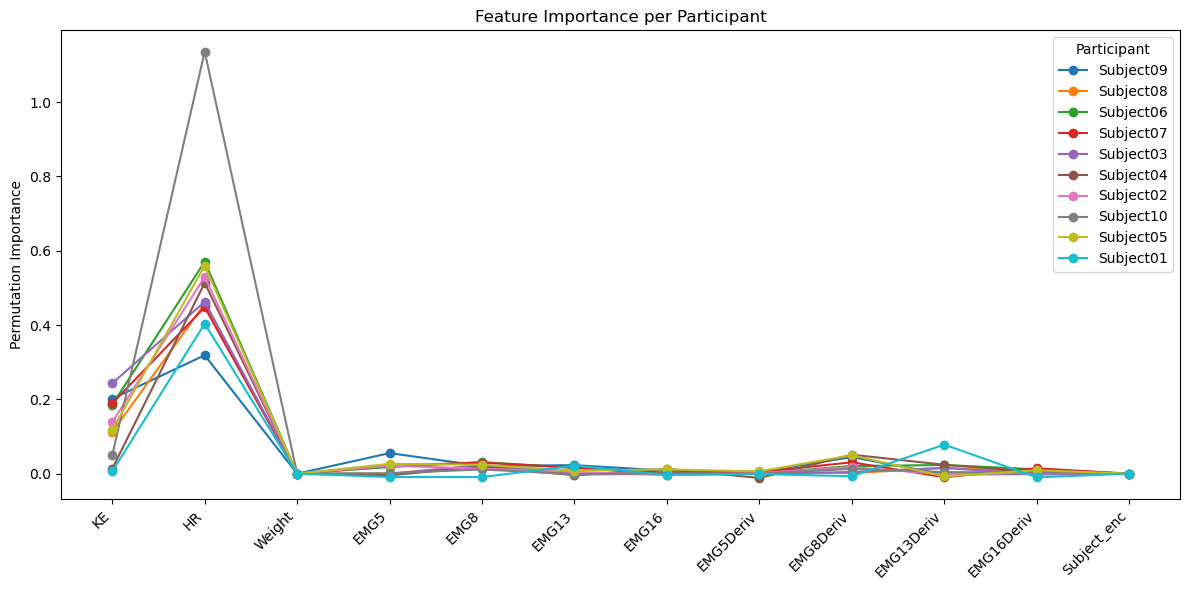

In [7]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
# USE THIS ONE - 15 SECONDS
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import seaborn as sns

# Load dataset
LR_df = merged_df
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject','KE', 'HR', 'EE', 'Weight', 'EMG5', 'EMG8', 'EMG13', 'EMG16', 'EMG5Deriv', 'EMG8Deriv', 'EMG13Deriv', 'EMG16Deriv']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values


x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]

uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, RMSETrain, mseTest, RMSETest, r2train, r2test, normRMSETrain, normRMSETest = [], [], [], [], [], [], [], []
fold_feature_importance = []
fold_subjects = []
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_subject = np.unique(original_subject_labels[test_idx])[0]
    fold_subjects.append(test_subject)

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    max_train = y_train.max()
    min_train = y_train.min()
    max_test = y_test.max()
    min_test = y_test.min()

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_RMSE_train = fold_mse_train ** 0.5
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_RMSE_test = fold_mse_test ** 0.5
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)
    foldNormRMSETrain = fold_RMSE_train / (max_train - min_train)
    foldNormRMSETest = fold_RMSE_test / (max_test - min_test)

    mseTrain.append(fold_mse_train)
    RMSETrain.append(fold_RMSE_train)
    mseTest.append(fold_mse_test)
    RMSETest.append(fold_RMSE_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)
    normRMSETrain.append(foldNormRMSETrain)
    normRMSETest.append(foldNormRMSETest)

    perm_importance = permutation_importance(model, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm_importance.importances_mean)

    # Print per-fold results
    print(f"Test Subject: {test_subject}")
    print(f"     Train RMSE: {fold_mse_train**0.5:.4f} , Test RMSE: {fold_mse_test**0.5:.4f}")
    print(f"     Train Normalized RMSE: {foldNormRMSETrain:.4f}, Test Normalized RMSE: {foldNormRMSETest:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

print("\n")
print(f"Average RMSE Train: {np.mean(mseTrain):.4f} , Average RMSE Test: {np.mean(mseTest):.4f}")
print(f"Average Train Normalized RMSE:  {np.mean(normRMSETrain):.4f} , Test Normalized RMSE:  {np.mean(normRMSETest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")


fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)

# Plot feature importance per participant
plt.figure(figsize=(12, 6))
for idx, subject in enumerate(fold_subjects):
    plt.plot(x.columns, fi_df.iloc[idx], marker='o', label=subject)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance per Participant")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import pandas as pd
from scipy import signal, interpolate
import warnings
warnings.filterwarnings("ignore")

# Constants
fs_ke = 128
fs_emg = 1000.0
fs_deriv = 1000
fs_hr_target = 10
channels = [5, 8, 13, 16]
window_sec = 0.1
samples_per_window = int(window_sec * fs_deriv)
window_sec_hr = 1.0
samples_per_window_hr = int(window_sec_hr * fs_hr_target)

# Prepare bandpass filter for EMG derivatives (50-150 Hz)
low = 50
high = 150
nyquist = fs_deriv / 2
low_c = low / nyquist
high_c = high / nyquist
order = 4
a_filt, b_filt = signal.butter(order, [low_c, high_c], btype='band')

# Prepare bandpass filter for HR derivatives (0.01-0.5 Hz)
low_hr = 0.01
high_hr = 0.5
nyquist_hr = fs_hr_target / 2
low_c_hr = low_hr / nyquist_hr
high_c_hr = high_hr / nyquist_hr
order_hr = 2
b_filt_hr, a_filt_hr = signal.butter(order_hr, [low_c_hr, high_c_hr], btype='band')

# RMS function
def rms(signal):
    mag = np.sqrt(np.mean(signal**2))
    direction = np.sign(np.mean(signal))
    return direction * mag

subjects = ('Subject01', 'Backwards')

# Master list to store all rows
all_rows = []

print("Processing all subjects and activities...")

subjects = [("Subject01","Backwards")]

for subject in result.keys():
    if subject[0] == "Subject02" and subject[1] in ['Backwards','Backwards2']:
        continue
    if subject[0] == "Subject05" and subject[1] in ['Cycling','Cycling2']:
        continue
    
    print(f"Processing {subject[0]} - {subject[1]}...")
    
    indDF = globals()[subject[0]].astype(int)
    valid_times = indDF[subject[1]][indDF[subject[1]] != 0].reset_index(drop=True)
    
    idx = list(sorted(set([k[0] for k in result.keys()]))).index(subject[0])
    subject_mass = mass[idx]
    mNorm = mass[idx] / 82.2
    
    start_time = 360
    end_time = int(valid_times.iloc[-1])
    
    # ------------------- KE ----------------------------------------
    accel_data = result[subject[0]][subject[1]]['APDM_Accel']['Data']
    
    segments = [
        {'Name': 'W', 'I': 0.02654, 'mass': 0, 'dist': 0, 'columns': [5, 6, 7]},
        {'Name': 'C', 'I': 0.33201, 'mass': 0, 'dist': 0, 'columns': [14, 15, 16]},
        {'Name': 'AL', 'I': 0.06397, 'mass': 0, 'dist': 0, 'columns': [23, 24, 25]},
        {'Name': 'AR', 'I': 0.06271, 'mass': 0, 'dist': 0, 'columns': [32, 33, 34]}
    ]
    
    KE_df = pd.DataFrame()
    
    for segment in segments:
        segment_name = segment['Name']
        I = segment['I'] * mNorm
        cols = segment['columns']
        m = segment['mass']
        r = segment['dist']
        
        x, y, z = [np.nan_to_num(accel_data[:, c], nan=0.0) for c in cols]
        omega = np.sqrt(x**2 + y**2 + z**2)
        KE = 0.5 * (I + (m*(0.5*r)**2)) * omega**2
        KE_df[segment_name] = KE
    
    KE_df['total'] = (KE_df['W'] + KE_df['C'] + KE_df['AL'] + KE_df['AR'])
    KE_df.to_csv('/Users/katbutler/MetabolicCost/kineticenergy.csv', index=False)
    
    #----------------------------EE-------------------------------
    VO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vo2]
    VCO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vco2]
    EE = (16.58 * VO2 + 4.15 * VCO2) / mass[0]
    
    ind = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, code]
    ind = ind[:-1] - ind[1:]
    bool_ind = ind != 0.0
    indShift = np.where(bool_ind)[0]
    indShift = np.concatenate((indShift, [len(ind)]))
    
    eePoints = []
    T_first_phase = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[0], 0]
    timeM3_first = T_first_phase - (3 * 60)
    bool_time_first = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3_first
    threeMin_first = indShift[0] - np.max(np.where(bool_time_first)[0])
    EE_avg_first = np.mean(EE[indShift[0] - threeMin_first:indShift[0]])
    
    for i in range(len(indShift)):
        if i == 0:
            eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin_first:indShift[i]] - EE_avg_first), 4)))
        elif i == len(indShift) - 1:
            eePoints.append(float(np.round(np.mean(EE[-threeMin_first:] - EE_avg_first), 4)))
        else:
            T = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[i], 0]
            timeM3 = T - (3 * 60)
            bool_time = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3
            threeMin = indShift[i] - np.max(np.where(bool_time)[0])
            eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin:indShift[i]] - EE_avg_first), 4)))
    
    eePoints = eePoints[1:-1]
    
    #----------------------------HR-------------------------------
    metab_data = result[subject[0]][subject[1]]['Metabolics_System']['Data']
    time_col = metab_data[:, 0]
    hr_col = metab_data[:, 8]
    
    standing_mask = (time_col >= 3 * 60) & (time_col <= 6 * 60)
    standing_avg_hr = np.mean(hr_col[standing_mask])
    
    hr_time_start = time_col[0]
    hr_time_end = time_col[-1]
    time_10hz = np.arange(hr_time_start, hr_time_end, 1.0 / fs_hr_target)
    
    interp_func = interpolate.interp1d(time_col, hr_col, kind='linear', bounds_error=False, fill_value='extrapolate')
    hr_10hz = interp_func(time_10hz)
    
    hr_filtered = signal.filtfilt(b_filt_hr, a_filt_hr, hr_10hz)
    
    #-----------------------------EMG-------------------------------------------
    emg_full = result[subject[0]][subject[1]]['EMG']['Data']
    emg_time = emg_full[:, 0]
    
    emg_channel_data = {}
    emg_deriv_data = {}
    
    for ch in channels:
        emg = np.nan_to_num(emg_full[:, ch], nan=0.0)
        
        lowcut = 30.0
        highcut = 350.0
        order = 5
        nyq = 0.5 * fs_emg
        b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='bandpass')
        filtered = signal.filtfilt(b, a, emg)
        rectified = np.abs(filtered)
        
        cutoff_lp = 5.0
        b_lp, a_lp = signal.butter(4, cutoff_lp / nyq, btype='low')
        lowPass = signal.filtfilt(b_lp, a_lp, rectified)
        emg_channel_data[ch] = lowPass
        
        signal_filt = np.nan_to_num(emg_filt(emg), nan=0.0)
        emg_deriv_data[ch] = signal_filt
    
    #--------------------------15 SECONDS-------------------------------------
    num_intervals = len(valid_times) - 1
    samples_per_fifteen = 15 * 128
    bins_per_interval = 24
    
    for i in range(num_intervals):
        interval_start = int(indDF[subject[1]][i]) * 128
        interval_end = int(indDF[subject[1]][i + 1]) * 128
        
        for b in range(bins_per_interval):
            bin_start = interval_start + b * samples_per_fifteen
            bin_end = bin_start + samples_per_fifteen
            
            if bin_end > interval_end:
                break
            
            row_data = {
                'Subject': subject[0],
                'Activity': subject[1],
                'Time': bin_start / 128,
                'Weight': subject_mass
            }
            
            mean_val = round(KE_df['total'].iloc[bin_start:bin_end].mean(), 4)
            row_data['KE'] = mean_val
            
            row_data['EE'] = eePoints[i]
            
            bin_start_sec = bin_start / 128
            bin_end_sec = bin_end / 128
            mask = (time_col >= bin_start_sec) & (time_col < bin_end_sec)
            row_data['HR'] = float(np.round(np.mean(hr_col[mask]) - standing_avg_hr, 4))
            
            # HR Derivative
            start_idx_hr = int(bin_start_sec * fs_hr_target)
            end_idx_hr = int(bin_end_sec * fs_hr_target)
            deriv_values_hr = []
            
            for window_start in range(start_idx_hr, end_idx_hr, samples_per_window_hr):
                window_end = min(window_start + samples_per_window_hr, end_idx_hr)
                sig_bin_hr = hr_filtered[window_start:window_end]
                t_bin_local_hr = np.arange(len(sig_bin_hr)) / fs_hr_target
                deriv = num_derivative(t_bin_local_hr, sig_bin_hr, 'x_1')
                deriv = deriv.flatten()
                deriv_values_hr.append(deriv.mean())
            
            row_data['HRDeriv'] = (rms(np.array(deriv_values_hr)))
            
            # EMG
            start_idx_emg = int(bin_start_sec * fs_emg)
            end_idx_emg = int(bin_end_sec * fs_emg)
            
            for ch in channels:
                seg = emg_channel_data[ch][start_idx_emg:end_idx_emg]
                row_data[f'EMG{ch}'] = float(np.round(np.mean(seg), 4))
            
            # EMG Derivatives
            for ch in channels:
                deriv_values_in_bin = []
                for window_start in range(start_idx_emg, end_idx_emg, samples_per_window):
                    window_end = min(window_start + samples_per_window, end_idx_emg)
                    sig_bin = emg_deriv_data[ch][window_start:window_end]
                    t_bin_local = np.arange(len(sig_bin)) / fs_deriv
                    sig_bin = np.nan_to_num(sig_bin, nan=0.0, posinf=0.0, neginf=0.0)
                    deriv = num_derivative(t_bin_local, sig_bin, 'x_1')
                    deriv = deriv.flatten()
                    deriv_values_in_bin.append(deriv.mean())
                
                row_data[f'EMG{ch}Deriv'] = (np.array(deriv_values_in_bin).mean())
            
            all_rows.append(row_data)

# ---------------------------- FINAL DF ------------------------------------
print("\nCreating final dataframe...")
merged_df = pd.DataFrame(all_rows)

# Reorder columns
wanted_cols = ['Subject', 'Activity', 'Time', 'KE', 'HR', 'HRDeriv', 'EE', 'Weight', 
               'EMG5', 'EMG8', 'EMG13', 'EMG16', 
               'EMG5Deriv', 'EMG8Deriv', 'EMG13Deriv', 'EMG16Deriv']
final_cols = [col for col in wanted_cols if col in merged_df.columns]
merged_df = merged_df[final_cols]

Processing all subjects and activities...
Processing Subject01 - Backwards...
Processing Subject01 - Cycling...
Processing Subject01 - Incline...
Processing Subject01 - Running...
Processing Subject01 - Walking...
Processing Subject02 - Cycling...
Processing Subject02 - Incline...
Processing Subject02 - Running...
Processing Subject02 - Stairs...
Processing Subject02 - Walking...
Processing Subject03 - Backwards...
Processing Subject03 - Cycling...
Processing Subject03 - Incline...
Processing Subject03 - Running...
Processing Subject03 - Stairs...
Processing Subject03 - Walking...
Processing Subject04 - Backwards...
Processing Subject04 - Cycling...
Processing Subject04 - Incline...
Processing Subject04 - Running...
Processing Subject04 - Stairs...
Processing Subject04 - Walking...
Processing Subject05 - Backwards...
Processing Subject05 - Incline...
Processing Subject05 - Running...
Processing Subject05 - Stairs...
Processing Subject05 - Walking...
Processing Subject06 - Backwards...


In [9]:
print(merged_df.head(5000))
merged_df.to_csv('/Users/katbutler/MetabolicCost/merged.csv', index=False)

        Subject   Activity    Time      KE       HR   HRDeriv      EE  Weight  \
0     Subject01  Backwards   360.0  0.1312   4.2409  0.003146  1.3861   63.49   
1     Subject01  Backwards   375.0  0.1456  11.4909  0.001157  1.3861   63.49   
2     Subject01  Backwards   390.0  0.1390  12.8909 -0.002938  1.3861   63.49   
3     Subject01  Backwards   405.0  0.1403  12.4909 -0.001302  1.3861   63.49   
4     Subject01  Backwards   420.0  0.1289  11.4909 -0.003054  1.3861   63.49   
...         ...        ...     ...     ...      ...       ...     ...     ...   
4768  Subject10    Walking  1365.0  0.7586  15.7892  0.002585  2.6765   58.05   
4769  Subject10    Walking  1380.0  0.7754  18.5035  0.003743  2.6765   58.05   
4770  Subject10    Walking  1395.0  0.7776  20.3607 -0.004081  2.6765   58.05   
4771  Subject10    Walking  1410.0  0.7532  17.0273  0.002502  2.6765   58.05   
4772  Subject10    Walking  1425.0  0.7905  19.5035  0.002851  2.6765   58.05   

        EMG5    EMG8   EMG1

In [10]:
merged_df_train = merged_df.copy()

# Drop all EMG derivative columns
emg_derivs = ['EMG5Deriv', 'EMG8Deriv', 'EMG13Deriv', 'EMG16Deriv']
merged_df_train = merged_df_train.drop(columns=emg_derivs)

# Rename EMG columns to new names
merged_df_train = merged_df_train.rename(columns={
    'EMG5': 'rsol',
    'EMG8': 'rbf',
    'EMG13': 'lsol',
    'EMG16': 'lbf'
})

# Check the result
print(merged_df_train.head())


     Subject   Activity   Time      KE       HR   HRDeriv      EE  Weight  \
0  Subject01  Backwards  360.0  0.1312   4.2409  0.003146  1.3861   63.49   
1  Subject01  Backwards  375.0  0.1456  11.4909  0.001157  1.3861   63.49   
2  Subject01  Backwards  390.0  0.1390  12.8909 -0.002938  1.3861   63.49   
3  Subject01  Backwards  405.0  0.1403  12.4909 -0.001302  1.3861   63.49   
4  Subject01  Backwards  420.0  0.1289  11.4909 -0.003054  1.3861   63.49   

     rsol     rbf    lsol     lbf  
0  0.0085  0.0113  0.0131  0.0124  
1  0.0046  0.0098  0.0095  0.0107  
2  0.0042  0.0090  0.0079  0.0106  
3  0.0035  0.0086  0.0066  0.0097  
4  0.0046  0.0099  0.0040  0.0081  


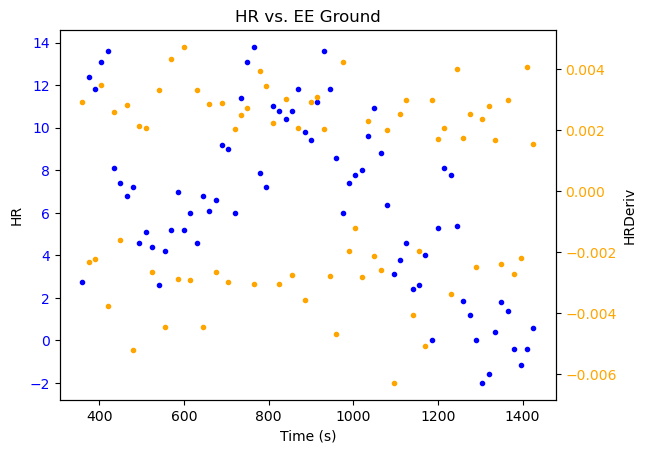

In [11]:
subject1Walk = merged_df[(merged_df['Subject'] == 'Subject01') & (merged_df['Activity'] == 'Walking')]

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('HR')
ax1.plot(subject1Walk['Time'], subject1Walk['HR'],'.',color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('HRDeriv')
ax2.plot(subject1Walk['Time'],subject1Walk['HRDeriv'],'.', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.xlabel('Time (s)')
plt.title('HR vs. EE Ground')
plt.show()

In [1]:
merged_df_train.to_pickle("/Users/katbutler/MetabolicCost/merged_df_train.pkl")

NameError: name 'merged_df_train' is not defined

In [3]:
import pandas as pd
merged_df_train = pd.read_pickle("/Users/katbutler/MetabolicCost/merged_df_train.pkl")

Test Subject: Subject09
     Train RMSE: 1.0555 , Test RMSE: 0.9651
     Train Normalized RMSE: 0.0730, Test Normalized RMSE: 0.0761
     Train R²:  0.8830 , Test R²:  0.9039


Test Subject: Subject08
     Train RMSE: 1.0637 , Test RMSE: 0.9391
     Train Normalized RMSE: 0.0735, Test Normalized RMSE: 0.0905
     Train R²:  0.8850 , Test R²:  0.8718


Test Subject: Subject06
     Train RMSE: 1.0381 , Test RMSE: 1.1501
     Train Normalized RMSE: 0.0718, Test Normalized RMSE: 0.0981
     Train R²:  0.8874 , Test R²:  0.8581


Test Subject: Subject07
     Train RMSE: 0.9985 , Test RMSE: 1.9332
     Train Normalized RMSE: 0.0747, Test Normalized RMSE: 0.1361
     Train R²:  0.8901 , Test R²:  0.7104


Test Subject: Subject03
     Train RMSE: 1.0318 , Test RMSE: 1.1829
     Train Normalized RMSE: 0.0713, Test Normalized RMSE: 0.0956
     Train R²:  0.8877 , Test R²:  0.8573


Test Subject: Subject04
     Train RMSE: 1.0387 , Test RMSE: 1.1539
     Train Normalized RMSE: 0.0718, Test Normal

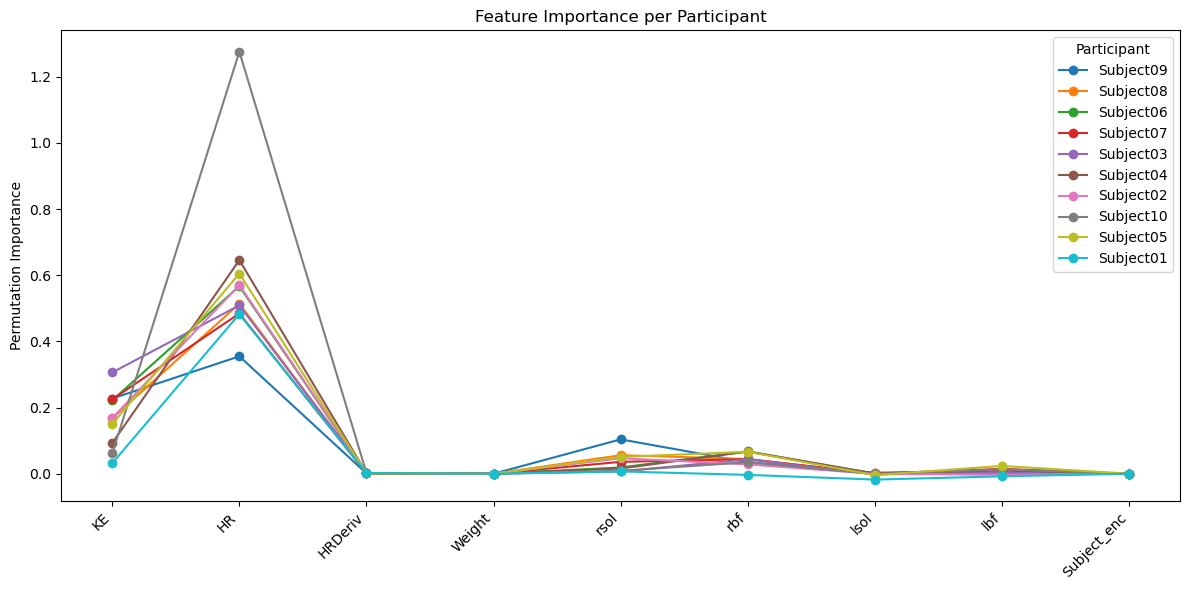

In [6]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
# USE THIS ONE - 15 SECONDS
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
LR_df = merged_df_train
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject','KE', 'HR', 'HRDeriv','EE', 'Weight', 'rsol', 'rbf', 'lsol', 'lbf']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values


x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]

uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, RMSETrain, mseTest, RMSETest, r2train, r2test, normRMSETrain, normRMSETest = [], [], [], [], [], [], [], []
fold_feature_importance = []
fold_subjects = []
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_subject = np.unique(original_subject_labels[test_idx])[0]
    fold_subjects.append(test_subject)

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    max_train = y_train.max()
    min_train = y_train.min()
    max_test = y_test.max()
    min_test = y_test.min()

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_RMSE_train = fold_mse_train ** 0.5
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_RMSE_test = fold_mse_test ** 0.5
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)
    foldNormRMSETrain = fold_RMSE_train / (max_train - min_train)
    foldNormRMSETest = fold_RMSE_test / (max_test - min_test)

    mseTrain.append(fold_mse_train)
    RMSETrain.append(fold_RMSE_train)
    mseTest.append(fold_mse_test)
    RMSETest.append(fold_RMSE_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)
    normRMSETrain.append(foldNormRMSETrain)
    normRMSETest.append(foldNormRMSETest)

    perm_importance = permutation_importance(model, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm_importance.importances_mean)

    # Print per-fold results
    print(f"Test Subject: {test_subject}")
    print(f"     Train RMSE: {fold_mse_train**0.5:.4f} , Test RMSE: {fold_mse_test**0.5:.4f}")
    print(f"     Train Normalized RMSE: {foldNormRMSETrain:.4f}, Test Normalized RMSE: {foldNormRMSETest:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

print("\n")
print(f"Average RMSE Train: {np.mean(mseTrain):.4f} , Average RMSE Test: {np.mean(mseTest):.4f}")
print(f"Average Train Normalized RMSE:  {np.mean(normRMSETrain):.4f} , Test Normalized RMSE:  {np.mean(normRMSETest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")


fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)

# Plot feature importance per participant
plt.figure(figsize=(12, 6))
for idx, subject in enumerate(fold_subjects):
    plt.plot(x.columns, fi_df.iloc[idx], marker='o', label=subject)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance per Participant")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
import joblib

LR_df = merged_df_train
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[['Subject','KE', 'HR', 'HRDeriv','EE', 'Weight', 'rsol', 'rbf', 'lsol', 'lbf']]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

X = LR_df.drop(columns=["EE", "Subject", "Subject_enc"])
y = LR_df["EE"]

model_trainall = make_pipeline(
    MinMaxScaler(),
    SVR(kernel="linear")
)

model_trainall.fit(X, y)

joblib.dump(model_trainall, "ML_model_full.pkl")

['ML_model_full.pkl']

In [36]:
pd.set_option('display.max_rows', None)
merged_test_df = pd.read_pickle("/Users/katbutler/MetabolicCost/merged_test_df.pkl")


merged_test_df = merged_test_df.copy()

merged_test_df["ActiveTime"] = merged_test_df.groupby(["Subject","Activity","Condition"]).cumcount() * 15

min_active = (
    merged_test_df.groupby(["Subject","Activity","Condition"])["ActiveTime"]
    .max()
    .unstack()
    .min(axis=1)
)

trimmed_list = []

for (subject, activity), block in merged_test_df.groupby(["Subject","Activity"]):
    min_time = min_active.loc[(subject, activity)]
    for cond in ["Control","Suit"]:
        cond_block = block[block["Condition"] == cond]
        cond_trimmed = cond_block[cond_block["ActiveTime"] <= min_time]
        trimmed_list.append(cond_trimmed)

# Final trimmed dataframe
trimmed_test = pd.concat(trimmed_list).reset_index(drop=True)


Condition   Subject Activity    Control       Suit
0          Subject1    Dummy   6.864174   8.822928
1          Subject1     Fire   7.067795   8.445767
2          Subject1      Jog  14.033575  10.727122
3          Subject1   Stairs   9.749187  10.791635
4          Subject1     Walk   7.816458   9.731854
5          Subject1    Wheel   6.717936   7.367092
6          Subject2    Dummy   9.236793   9.089668
7          Subject2     Fire   8.535372   9.713990
8          Subject2      Jog  14.775943  16.427248
9          Subject2   Stairs  10.955282  12.310750
10         Subject2     Walk   9.163295  10.648135
11         Subject2    Wheel   8.263613   8.995631


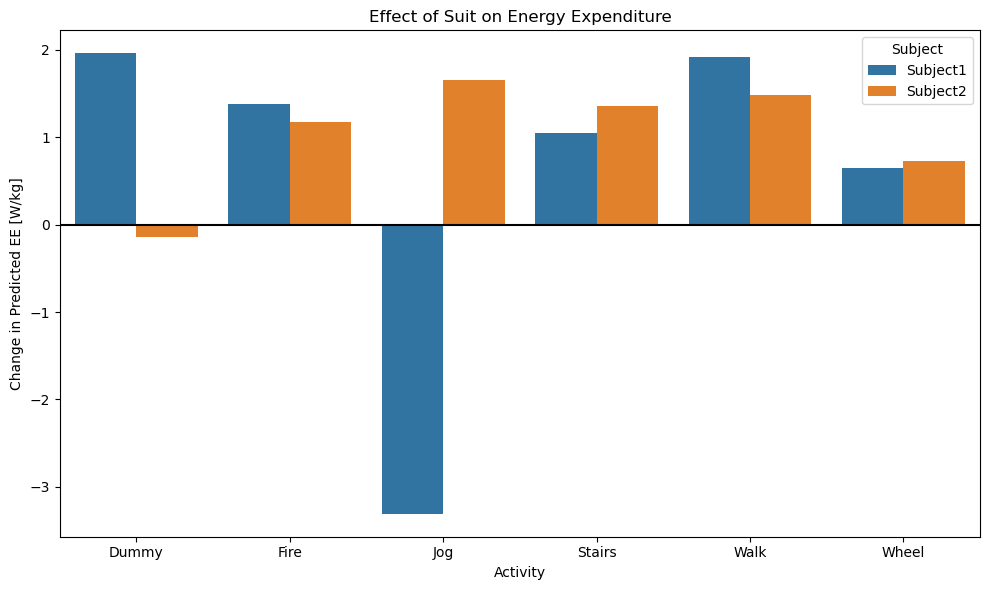

In [39]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model = joblib.load("ML_model_full.pkl")

new_data = trimmed_test.copy()

feature_cols = ["KE","HR","HRDeriv","Weight","rsol","rbf","lsol","lbf"]
X_new = new_data[feature_cols]

new_data["Predicted_EE"] = model.predict(X_new)

summary = (
    new_data
    .groupby(["Subject","Activity","Condition"])
    .agg(
        Mean_EE=("Predicted_EE","mean"),
        Std_EE=("Predicted_EE","std"),
        Samples=("Predicted_EE","size")
    )
    .reset_index()
)

comparison = summary.pivot_table(
    index=["Subject","Activity"],
    columns="Condition",
    values="Mean_EE"
).reset_index()

print(comparison) 
comparison["Delta_Suit_minus_Control"] = comparison["Suit"] - comparison["Control"]
comparison["Percent_Change"] = 100 * comparison["Delta_Suit_minus_Control"] / comparison["Control"]

plt.figure(figsize=(10,6))
sns.barplot(data=comparison, x="Activity", y="Delta_Suit_minus_Control", hue="Subject")
plt.axhline(0, color="black")
plt.ylabel("Change in Predicted EE [W/kg]")
plt.title("Effect of Suit on Energy Expenditure")
plt.tight_layout()
plt.show()
